# ImageNet Validation Script

The first thing we'll do is read in our saved model and logged metrics.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat

import torch
import torchvision

In [2]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)

cuda


In [3]:
def load_checkpoint(filename):
    checkpoint = torch.load(filename, map_location=device, weights_only=True)
    epochs = checkpoint['epochs']
    model_state_dict = checkpoint['model_state_dict']
    optimizer_state_dict = checkpoint['optimizer_state_dict']
    train_records = checkpoint['train_records']
    val_records = checkpoint['val_records']
    return (epochs, model_state_dict, optimizer_state_dict, 
            train_records, val_records)

In [4]:
epoch, model_state_dict, _, train_records, val_records = load_checkpoint("/workspace/imagenet-checkpoint.pt")

In [5]:
print(f"Training epoch is {epoch}")

Training epoch is 90


In [6]:
model = torchvision.models.resnet50()
model.load_state_dict(model_state_dict)
model.eval();

Next we'll write a function to plot our training and validation losses and accuracies.

In [7]:
def plot_metrics(
        epoch, train_records, val_records, 
        metrics=["Loss", "Top-1 accuracy", "Top-5 accuracy"],
    ):
    assert len(train_records) == len(val_records)
    train_records = train_records.to("cpu")
    val_records = val_records.to("cpu")
    n = len(train_records)
    fig, axs = plt.subplots(1, n, figsize=(3*n,3))
    x_train = np.linspace(0, epoch, len(train_records[0]), endpoint=False)
    x_val = np.linspace(0, epoch, len(val_records[0]), endpoint=True)
    for i, ax in enumerate(axs):
        ax.plot(x_train, train_records[i], label="Train")
        ax.plot(x_val, val_records[i], label="Val")
        ax.set_title(metrics[i])
        ax.set_ylim([0.0, None])
    fig.supxlabel("Iterations")
    axs[0].legend()
    fig.tight_layout()
    return fig, axs

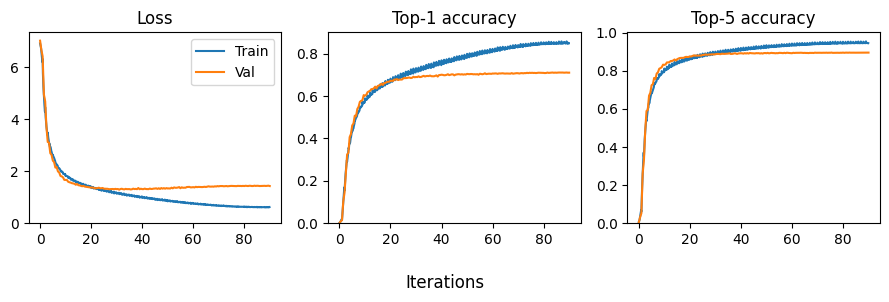

In [8]:
plot_metrics(epoch, train_records, val_records)
plt.show()

In [9]:
print(f"Validation top-1 accuracy: {val_records[1][-1]}")
print(f"Validation top-5 accuracy: {val_records[2][-1]}")

Validation top-1 accuracy: 0.7101200222969055
Validation top-5 accuracy: 0.8957200050354004


In [17]:
print(f"Training top-1 accuracy: {train_records[1][-1]}")
print(f"Training top-5 accuracy: {train_records[2][-1]}")

Training top-1 accuracy: 0.848828136920929
Training top-5 accuracy: 0.9454062581062317


# Test performance on validation dataset

In [10]:
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '../..'))
from utils.imagenet import get_plot_transform

In [11]:
nrows = ncols = 4
num_plot = nrows * ncols

In [12]:
bucket_path = '/workspace/imagenet'
val_ds = torchvision.datasets.ImageFolder(
    bucket_path + "/val", transform=get_plot_transform()
)
val_dl = torch.utils.data.DataLoader(
    val_ds, batch_size=num_plot, shuffle=True,
    num_workers=0, pin_memory=False, drop_last=False,
)

In [13]:
imgs, labels = next(iter(val_dl))
imgs_normalized = torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])(imgs)
preds = torch.argmax(model(imgs_normalized), dim=-1)
labels, preds = labels.numpy(), preds.numpy()

In [14]:
print(imgs.shape)
print(imgs_normalized.shape)
print(labels)
print(preds)

torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
[660 259 644 762 932 270 719 616 326 751 655 546 877  15 237 920]
[701 263 644 578 932 270 719 616 326 751 578 546 667  15 237 920]


In [15]:
meta = loadmat('/workspace/imagenet/ILSVRC2012_devkit_t12/data/meta.mat')
synsets = meta['synsets']

def get_idx_to_label():
    return {val_ds.class_to_idx[synset[0][1][0]]: 
            synset[0][2][0].split(',')[0] for synset in synsets[0:1000]}

idx_to_label = get_idx_to_label()

def plot_imgs(imgs, labels, preds):
    imgs = imgs.permute(0,2,3,1)
    fig, axs = plt.subplots(nrows, ncols, figsize=(3*nrows, 3*ncols))
    for i, xax in enumerate(axs):
        for j, ax in enumerate(xax):
            k = i*nrows + j
            ax.imshow(imgs[k])
            ax.set_title(f"Label: {idx_to_label[labels[k]]}\nPredicted: {idx_to_label[preds[k]]}")
    fig.suptitle("Model predictions on validation set")
    fig.tight_layout()

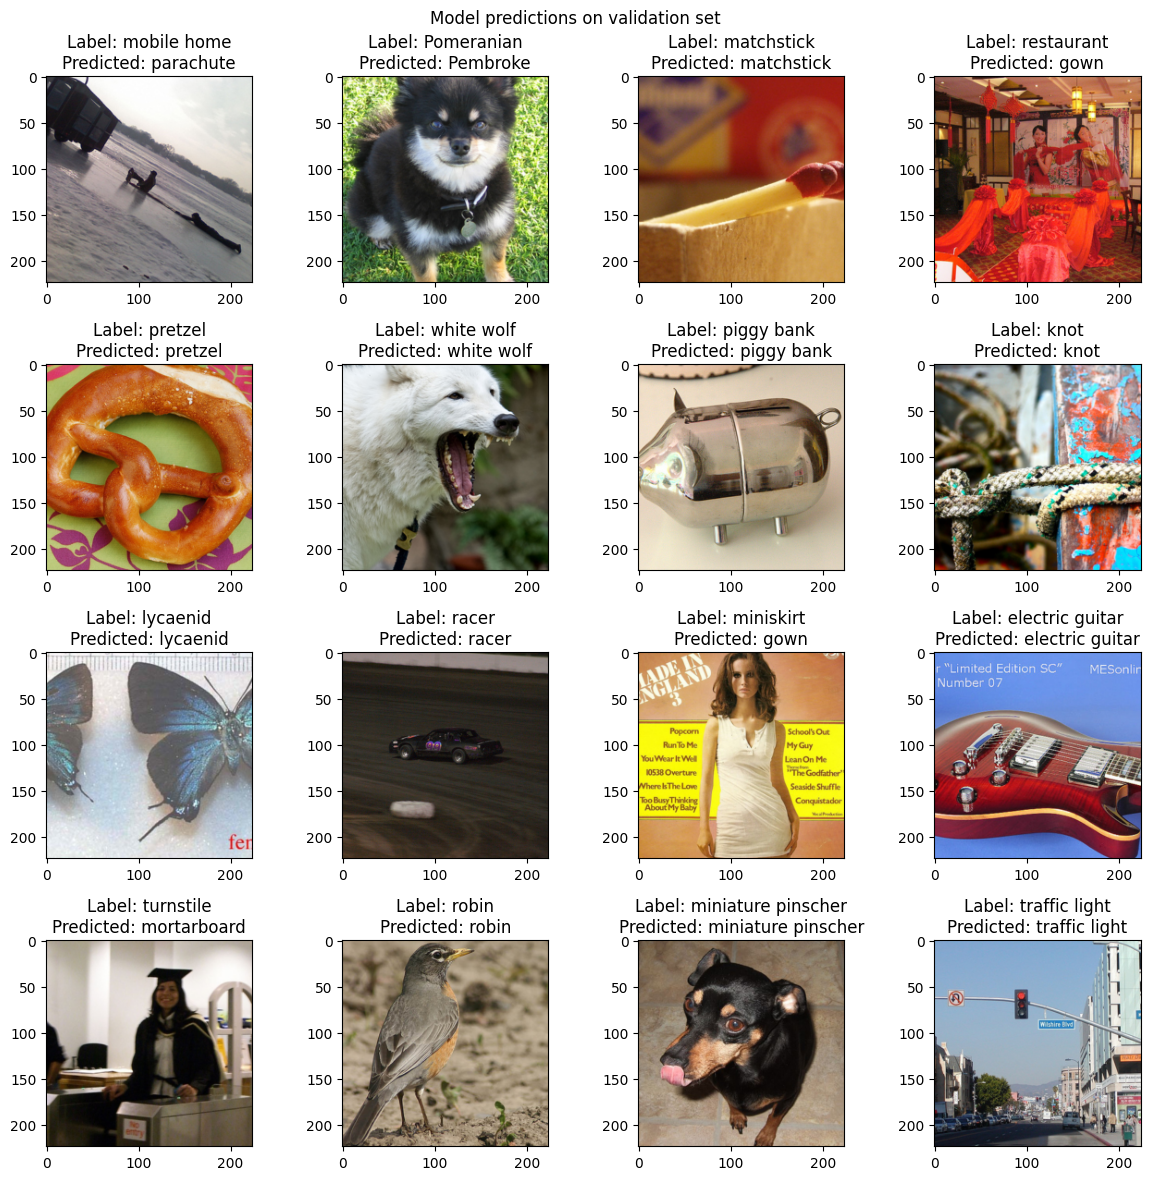

In [16]:
plot_imgs(imgs, labels, preds)
plt.show()